In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [43]:
classes = [
    "A_positive",
    "A_negative",
    "B_positive",
    "B_negative",
    "AB_positive",
    "AB_negative",
    "O_positive",
    "O_negative"
]

NUM_CLASSES = len(classes)

IMG_SIZE = 128
IMAGES_PER_CLASS = 250

print("Classes:", classes)
print("Number of classes:", NUM_CLASSES)

Classes: ['A_positive', 'A_negative', 'B_positive', 'B_negative', 'AB_positive', 'AB_negative', 'O_positive', 'O_negative']
Number of classes: 8


In [44]:
def generate_fingerprint(seed, size=128):
    rng = np.random.default_rng(seed)

    y, x = np.mgrid[
        -1:1:complex(size),
        -1:1:complex(size)
    ]

    angle = rng.uniform(0, np.pi)

    xr = (
        x * np.cos(angle)
        + y * np.sin(angle)
    )

    yr = (
        -x * np.sin(angle)
        + y * np.cos(angle)
    )

    frequency = rng.uniform(7, 11)

    pattern = np.sin(
        frequency * xr
        + 2.5 * np.sin(3 * yr)
    )

    # Create fingerprint ridges
    fingerprint = (
        pattern > 0
    ).astype(np.float32)

    # Slight blur-like smoothing
    noise = rng.normal(
        0,
        0.08,
        fingerprint.shape
    )

    fingerprint = fingerprint + noise

    fingerprint = np.clip(
        fingerprint,
        0,
        1
    )

    return fingerprint

In [45]:
X = []
y = []

for class_index, class_name in enumerate(classes):

    for image_index in range(IMAGES_PER_CLASS):

        seed = (
            class_index * 100000
            + image_index
        )

        image = generate_fingerprint(
            seed,
            IMG_SIZE
        )

        X.append(image)
        y.append(class_index)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (2000, 128, 128)
Labels shape: (2000,)


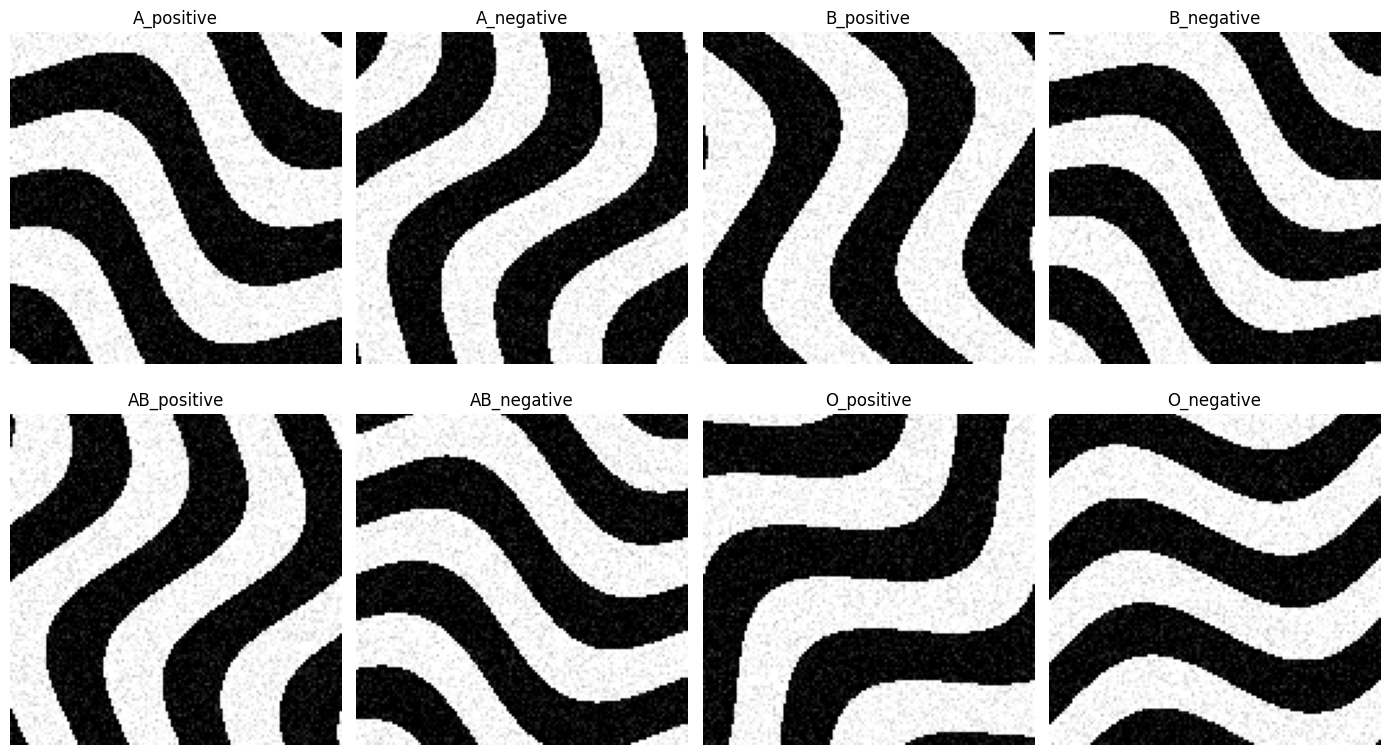

In [46]:
plt.figure(figsize=(14, 8))

for i in range(8):

    index = np.where(y == i)[0][0]

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        X[index],
        cmap="gray"
    )

    plt.title(classes[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
X = X[..., np.newaxis]

print("New shape:", X.shape)

New shape: (2000, 128, 128, 1)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1600, 128, 128, 1)
Testing : (400, 128, 128, 1)


In [49]:
model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,096 (12.61 MB)

 Trainable params: 3,305,096 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [51]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=1,
    batch_size=128,
    verbose=1
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 56s 5s/step - accuracy: 0.1117 - loss: 2.1116 - val_accuracy: 0.1000 - val_loss: 2.0794


In [52]:
# Evaluate the 1-epoch model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", f"{test_accuracy * 100:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")

Test Accuracy: 12.50%
Test Loss: 2.0799


In [53]:
# Make predictions

predictions = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    predictions,
    axis=1
)

print("Prediction completed!")

Prediction completed!


In [54]:
# Classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  A_positive       0.00      0.00      0.00        50
  A_negative       0.00      0.00      0.00        50
  B_positive       0.00      0.00      0.00        50
  B_negative       0.11      0.08      0.09        50
 AB_positive       0.00      0.00      0.00        50
 AB_negative       0.00      0.00      0.00        50
  O_positive       0.00      0.00      0.00        50
  O_negative       0.13      0.92      0.22        50

    accuracy                           0.12       400
   macro avg       0.03      0.12      0.04       400
weighted avg       0.03      0.12      0.04       400



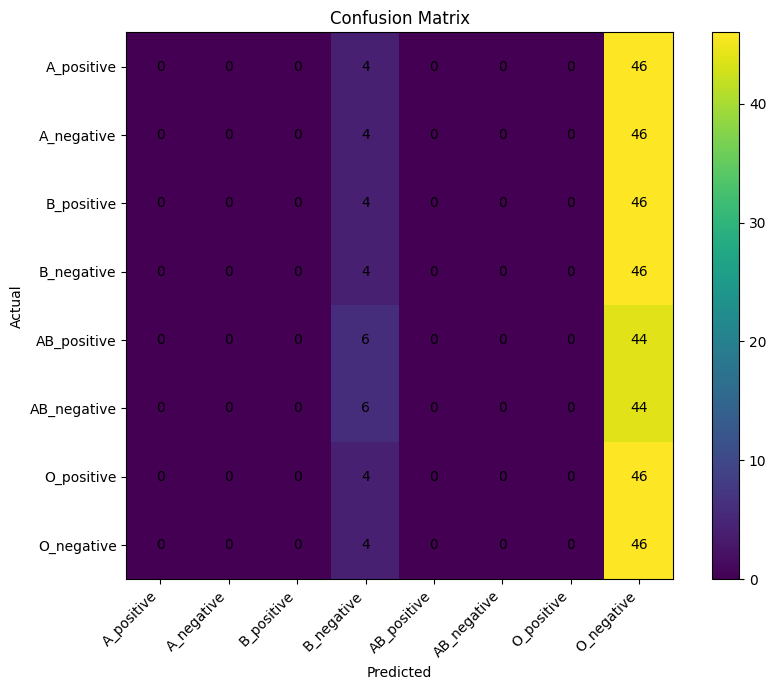

In [56]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

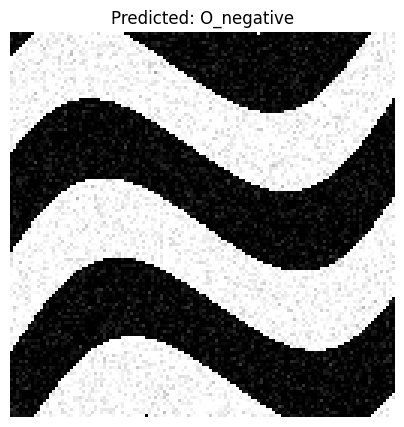

PREDICTION RESULT
Actual Blood Group    : O_negative
Predicted Blood Group : O_negative
Confidence            : 12.66%


In [57]:
# Select a random test image

test_index = np.random.randint(0, len(X_test))

sample = X_test[test_index]

actual_class = classes[y_test[test_index]]

prediction = model.predict(
    sample[np.newaxis, ...],
    verbose=0
)

predicted_index = np.argmax(prediction[0])

predicted_class = classes[predicted_index]

confidence = prediction[0][predicted_index] * 100

plt.figure(figsize=(5, 5))

plt.imshow(
    sample.squeeze(),
    cmap="gray"
)

plt.axis("off")

plt.title(
    f"Predicted: {predicted_class}"
)

plt.show()

print("=" * 40)
print("PREDICTION RESULT")
print("=" * 40)

print("Actual Blood Group    :", actual_class)
print("Predicted Blood Group :", predicted_class)
print("Confidence            :", f"{confidence:.2f}%")

In [58]:
from google.colab import files

print("Upload a fingerprint image:")

uploaded = files.upload()

Upload a fingerprint image:


Saving fingerprint image 2.jpg to fingerprint image 2 (1).jpg


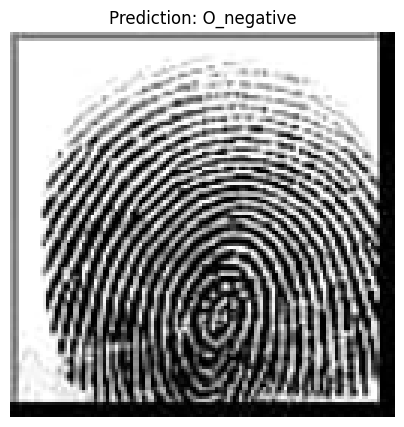

Predicted Blood Group: O_negative
Confidence: 12.65%


In [59]:
from PIL import Image

filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("L")

image = image.resize(
    (IMG_SIZE, IMG_SIZE)
)

image_array = np.array(
    image
).astype("float32") / 255.0

image_array = image_array[
    np.newaxis,
    ...,
    np.newaxis
]

prediction = model.predict(
    image_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_class = classes[
    predicted_index
]

confidence = (
    prediction[0][predicted_index] * 100
)

plt.figure(figsize=(5, 5))

plt.imshow(
    image_array[0].squeeze(),
    cmap="gray"
)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}"
)

plt.show()

print("Predicted Blood Group:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")